### Import librairies 

In [1]:
library(readxl)
library(ggfortify)
library(edgeR)
library(ggpubr)
library(ggrepel)

Loading required package: ggplot2

Loading required package: limma



In [2]:
scaled_df = read.csv('../data/merged_dataset.csv')
meta = read.csv('../data/merged_dataset_meta.csv')

In [3]:
common = rownames(scaled_df)[rownames(scaled_df)%in%rownames(meta)]
meta=meta[common,]
scaled_df=scaled_df[common,]

### Identify previous clusters in merged space 

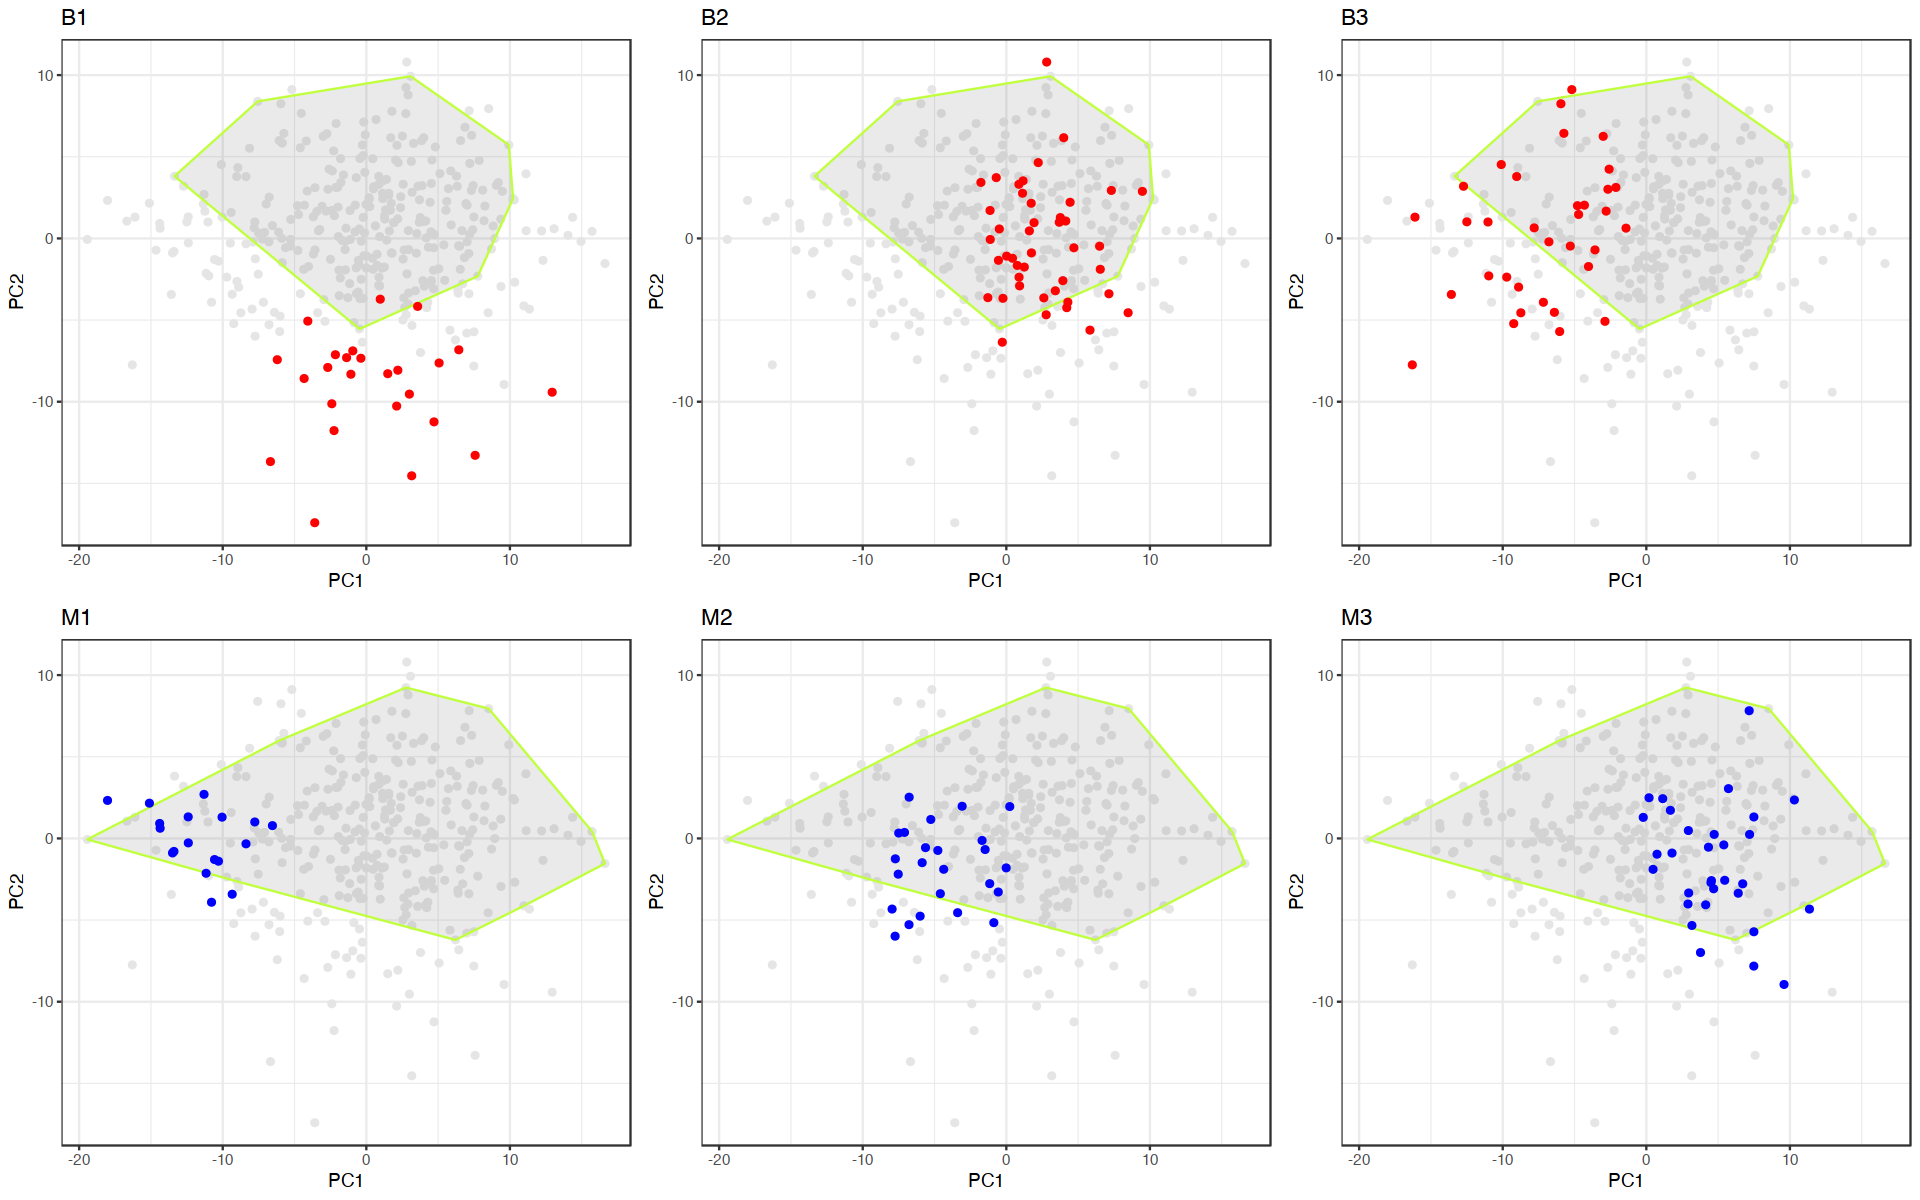

In [86]:
library(plyr)
pca = data.frame(prcomp(scaled_df)$x)
meta = meta
meta$PC1 = pca[,1]
meta$PC2 = pca[,2]

for(val in unique(meta$cluster)){
    meta[,gsub('-','.',val)] = meta$cluster == val
}

find_hull <- function(df) df[chull(df$PC1, df$PC2), ]
hulls <- ddply(subset(meta,grepl('B.CTL',cluster)), "cluster", find_hull)

p1=ggplot(meta,aes(PC1,PC2))+geom_point(col='grey90')+geom_polygon(data=hulls,alpha=.1,col='olivedrab1')+geom_point(data=subset(meta,B1=='TRUE'),col='red')+theme_bw()+ggtitle('B1')
p2=ggplot(meta,aes(PC1,PC2))+geom_point(col='grey90')+geom_polygon(data=hulls,alpha=.1,col='olivedrab1')+geom_point(data=subset(meta,B2=='TRUE'),col='red')+theme_bw()+ggtitle('B2')
p3=ggplot(meta,aes(PC1,PC2))+geom_point(col='grey90')+geom_polygon(data=hulls,alpha=.1,col='olivedrab1')+geom_point(data=subset(meta,B3=='TRUE'),col='red')+theme_bw()+ggtitle('B3')

find_hull <- function(df) df[chull(df$PC1, df$PC2), ]
hulls <- ddply(subset(meta,grepl('M.CTL',cluster)), "cluster", find_hull)

p5=ggplot(meta,aes(PC1,PC2))+geom_point(col='grey90')+geom_polygon(data=hulls,alpha=.1,col='olivedrab1')+geom_point(data=subset(meta,M1=='TRUE'),col='blue')+theme_bw()+ggtitle('M1')
p6=ggplot(meta,aes(PC1,PC2))+geom_point(col='grey90')+geom_polygon(data=hulls,alpha=.1,col='olivedrab1')+geom_point(data=subset(meta,M2=='TRUE'),col='blue')+theme_bw()+ggtitle('M2')
p7=ggplot(meta,aes(PC1,PC2))+geom_point(col='grey90')+geom_polygon(data=hulls,alpha=.1,col='olivedrab1')+geom_point(data=subset(meta,M3=='TRUE'),col='blue')+theme_bw()+ggtitle('M3')

options(repr.plot.width = 16, repr.plot.height = 10)

cowplot::plot_grid(p1,p2,p3,p5,p6,p7,ncol=3)

### Compare Control vs HFpEF differences between the 2 datasets in the merged space 

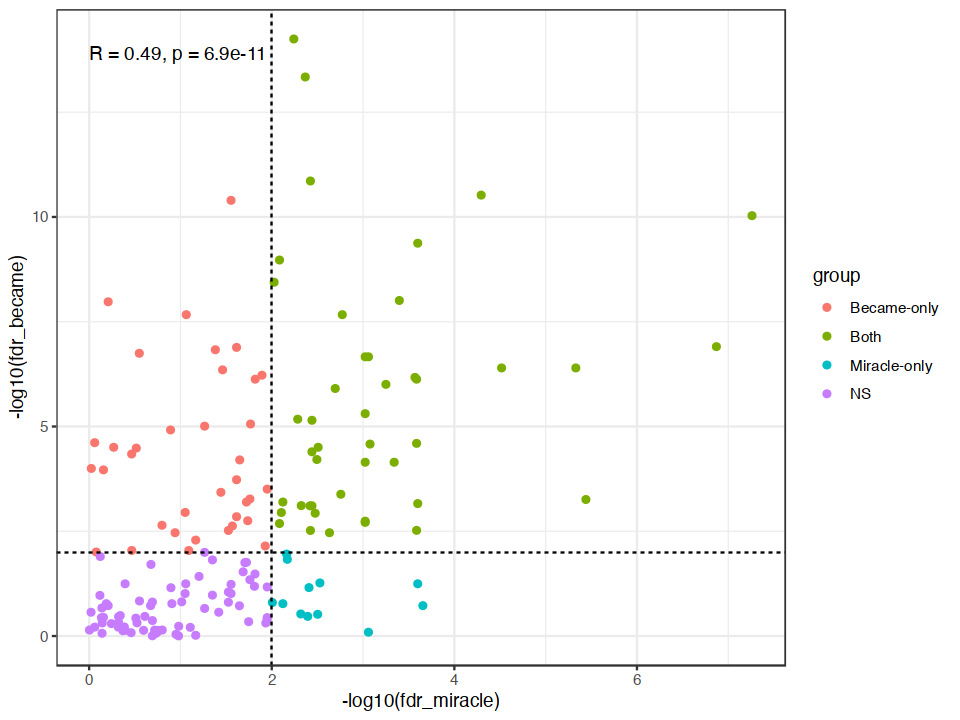

In [5]:
m2 = data.frame(scaled_df)

m2$cluster = meta[rownames(m2),'cluster']
m2$group = meta[rownames(m2),'group']
res = data.frame()
for(i in 1:(ncol(m2)-2)){
    m2_b = subset(m2,grepl('^B',cluster))
    m2_m = subset(m2,grepl('^M',cluster))
    test_m = t.test(m2_m[,i]~group,data=m2_m)
    test_b = t.test(m2_b[,i]~group,data=m2_b)
    pval_m = test_m$p.value
    pval_b = test_b$p.value
    res = rbind(res,c(pval_m,pval_b,colnames(m2)[i]))
}
res[,1] = as.numeric(res[,1])
res[,2] = as.numeric(res[,2])
colnames(res) = c('pval_miracle','pval_became','lipid')
res$fdr_miracle = p.adjust(res$pval_miracle, method = "fdr")
res$fdr_became = p.adjust(res$pval_became, method = "fdr")


res$group = 'NS'
res[which(res$fdr_miracle<0.01&res$fdr_became<0.01),'group'] = 'Both'
res[which(res$fdr_miracle<0.01&res$fdr_became>=0.01),'group'] = 'Miracle-only'
res[which(res$fdr_miracle>=0.01&res$fdr_became<0.01),'group'] = 'Became-only'

options(repr.plot.width = 8, repr.plot.height = 6)

ggplot(res,aes(-log10(fdr_miracle),-log10(fdr_became)))+
    geom_point(aes(col=group))+
    stat_cor()+
    theme_bw()+
    geom_hline(yintercept=-log10(0.01),linetype='dashed')+
    geom_vline(xintercept=-log10(0.01),linetype='dashed')

### Identify correlations between clusters in terms of average lipid profiles

In [6]:
options(repr.plot.width = 8, repr.plot.height = 6)

ag = aggregate(m2[,-c(ncol(m2)-1,ncol(m2))],by=list(m2$cluster),mean)
rownames(ag) = ag[,1]
cor_mat = cor(t(ag[,-c(1,ncol(ag))]))


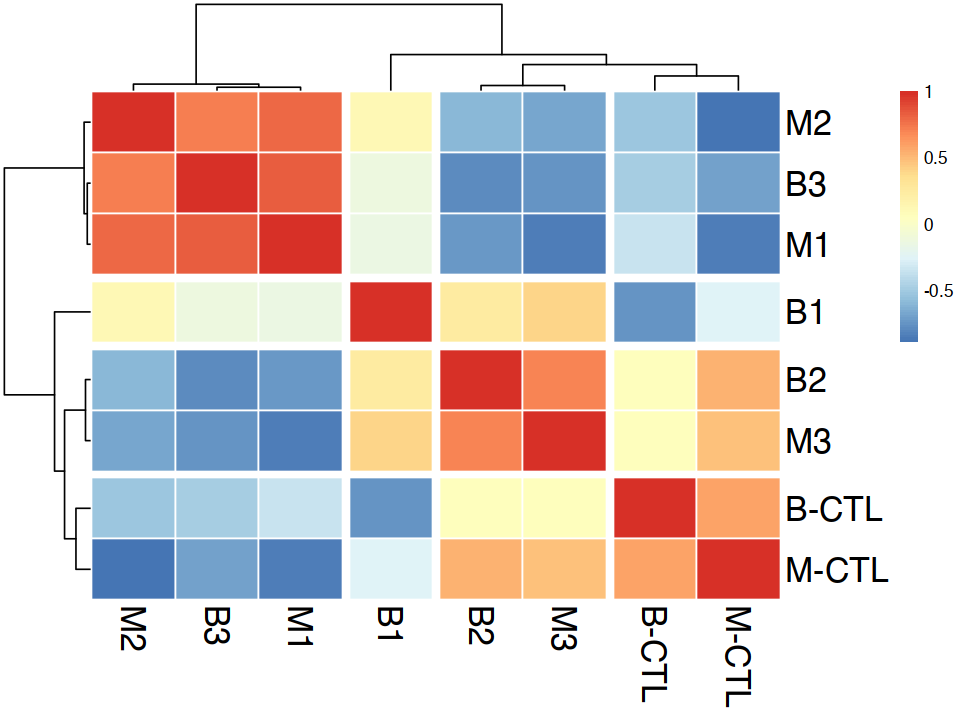

In [7]:
pheatmap::pheatmap(cor_mat,border_col='white',clustering_method='ward.D2',cutree_row=4,cutree_col=4,fontsize_col=20,fontsize_row=20)

### Identify statistical differences between clusters with ANOVA

In [20]:
head(became)

,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,⋯,X233,X234,X235,X236,X237,X238,X239,X240,X241,X242
,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,⋯,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
Metabolites,M371.3091T6.48,M369.2935T5.09,M399.3402T8.70,M427.3721T10.46,M425.3575T9.18,M423.3400T7.96,M539.5004T18.17,M537.4816T15.52,M651.6577T39.22,M631.6317T37.14,⋯,M949.8097T56.17,M947.7946T51.55,M947.7946T52.59,M947.7947T49.42,M945.7791T48.78,M945.7798T47.89,M945.7799T47.50,M969.7811T46.18,M981.8700T61.31,M975.8224T47.22
Compound.Name,POS:371.3091@6.48,POS:369.2935@5.09,POS:399.3402@8.70,POS:427.3721@10.46,POS:425.3575@9.18,POS:423.3400@7.96,POS:539.5004@18.17,POS:537.4816@15.52,POS:651.6577@39.22,POS:631.6317@37.14,⋯,POS:949.8097@56.17,POS:947.7946@51.55,POS:947.7946@52.59,POS:947.7947@49.42,POS:945.7791@48.78,POS:945.7798@47.89,POS:945.7799@47.50,POS:969.7811@46.18,POS:981.8700@61.31,POS:975.8224@47.22
Lipid ID,C14:0 Car,C14:1 Car,C16:0 Car,C18:0 Car,C18:1 Car,C18:2 Car,C26:0 Car,C26:1 Car,Cer(d18:0/24:0),Cer(d18:0/24:1)-a,⋯,TG58:7,TG58:8,TG58:8,TG58:8,TG58:9,TG58:9,TG58:9,TG60:11,TG60:5,TG60:8
Lipid suclasses,Acylcarnitines,Acylcarnitines,Acylcarnitines,Acylcarnitines,Acylcarnitines,Acylcarnitines,Acylcarnitines,Acylcarnitines,Ceramides,Ceramides,⋯,Triglycerides,Triglycerides,Triglycerides,Triglycerides,Triglycerides,Triglycerides,Triglycerides,Triglycerides,Triglycerides,Triglycerides
Log2 Fold-change(HFpEFvs ctl),0.3697714125,0.4797222464,0.3893145736,0.1603590177,0.5663651381,0.6155108397,0.2593430563,0.6257797103,-0.2178855315,0.5292264669,⋯,0.3576380383,0.1381116514,0.5259391088,0.0424245281,0.3907554764,0.0295312934,0.0989391379,0.0021101830,0.4381395459,0.0210072902
P-value (HFpEFvs ctl),6.907453e-03,8.963929e-03,2.492206e-03,8.067249e-02,3.258406e-04,7.640507e-06,2.607340e-03,8.815542e-11,4.442797e-02,3.181840e-05,⋯,1.842026e-02,3.958975e-01,2.458389e-03,8.210175e-01,3.713748e-02,8.580221e-01,5.571069e-01,9.903474e-01,5.804262e-06,8.742760e-01


In [55]:
became = data.frame(read_xlsx('../data/BECAME1_LipidomicData_lipidesidentifiés_161lipidesCommuns.xlsx',sheet=1))
became = data.frame(read_xlsx('../data/BECAME1_LipidomicData_lipidesidentifiés.xlsx',sheet=1))



became_meta = data.frame(read_xlsx('../data/BECAME1_LipidomicData_lipidesidentifiés_161lipidesCommuns.xlsx',sheet=2))
# became_meta = data.frame(read_xlsx('../data/BECAME1_LipidomicData_lipidesidentifiés.xlsx',sheet=2))

rownames(became_meta) = paste0('X',became_meta[,1])

became_num = became[,-c(1:10)]
for(i in 1:ncol(became_num)){became_num[,i]=as.numeric(became_num[,i])}
became_num = data.frame(log(became_num))

became_scaled = data.frame(t(scaled_df[rownames(became_meta),]))

In [56]:
common = rownames(became_meta)[rownames(became_meta)%in%colnames(became_num)]
became_num = became_num[,common]
became_meta = became_meta[common,]
factor(became_meta[colnames(became_num),'cluster.Became'])

[1] 1    1    3    2    2    2    1    1    2    2    2    3    2    3    3   
 [16] 2    2    2    3    1    2    2    3    1    3    1    2    3    2    2   
 [31] 1    3    3    3    1    3    1    1    1    2    1    2    1    3    3   
 [46] 1    3    2    2    1    2    1    3    1    2    2    3    1    3    3   
 [61] 2    2    2    2    2    3    3    2    3    1    2    2    1    3    2   
 [76] 2    3    2    1    1    2    3    1    2    3    2    1    3    3    3   
 [91] 3    3    2    2    2    1    3    3    3    2    1    2    2    2    2   
[106] Ctrl Ctrl Ctrl Ctrl Ctrl Ctrl Ctrl Ctrl Ctrl Ctrl Ctrl Ctrl Ctrl Ctrl Ctrl
[121] Ctrl Ctrl Ctrl Ctrl Ctrl Ctrl Ctrl Ctrl Ctrl Ctrl Ctrl Ctrl Ctrl Ctrl Ctrl
[136] Ctrl Ctrl Ctrl Ctrl Ctrl Ctrl Ctrl Ctrl Ctrl Ctrl Ctrl Ctrl Ctrl Ctrl Ctrl
[151] Ctrl Ctrl Ctrl Ctrl Ctrl Ctrl Ctrl Ctrl Ctrl Ctrl Ctrl Ctrl Ctrl Ctrl Ctrl
[166] Ctrl Ctrl Ctrl Ctrl Ctrl Ctrl Ctrl Ctrl Ctrl Ctrl Ctrl Ctrl
Levels: 1 2 3 Ctrl

In [58]:
res=data.frame()
for(i in 1:nrow(became_num)){
    test_og = aov(as.numeric(became_num[i,])~factor(became_meta[colnames(became_num),'cluster.Became']))

    p_value_og <- summary(test_og)[[1]][["Pr(>F)"]][1]
    
    res = rbind(res,c(p_value_og,rownames(became_num)[i]))

}

In [59]:
res$compound_name = became[rownames(res),'Lipid.ID']

In [60]:
colnames(res)[1:2] = c('pval_og','compound_id')
res$compound_name = factor(res$compound_name,levels=unique(res[order(-as.numeric(res$pval_og)),'compound_name']))
res$pval_og = as.numeric(res$pval_og)

res = res[order(res$pval_og),]

res$unique_values <- with(res, ave(as.character(compound_name), as.character(compound_name), FUN = function(x) {
  if (sum(duplicated(x)) > 0) {
    seq_along(x)
  } else {
    rep(1, length(x))
  }
}))
res$unique_name = paste(res$compound_name,res$unique_values,sep='.')
res$unique_name = factor(res$unique_name,levels=unique(res[order(-as.numeric(res$pval_og)),'unique_name']))

In [77]:
subset(res,pval_og<0.000000000000001)

,pval_og,compound_id,compound_name,unique_values,unique_name
,<dbl>,<chr>,<fct>,<chr>,<fct>
80,2.346776e-20,80,PC(O-18:1/16:0),1,PC(O-18:1/16:0).1
93,3.646795e-20,93,PC(14:0_20:5),1,PC(14:0_20:5).1
166,1.719947e-19,166,SM(d18:0/16:0)-OH,1,SM(d18:0/16:0)-OH.1
94,3.087909e-19,94,PC(14:0_22:6),1,PC(14:0_22:6).1
60,1.719520e-18,60,PC(16:0_20:4(OH)),1,PC(16:0_20:4(OH)).1
113,2.033027e-18,113,PC(18:2_20:4),1,PC(18:2_20:4).1
62,1.445368e-17,62,PC(O-16:0/16:0),1,PC(O-16:0/16:0).1
114,1.726776e-17,114,PC(18:2_20:5),1,PC(18:2_20:5).1
5,6.840992e-17,5,C18:1 Car,1,C18:1 Car.1


In [42]:
became_scaled = data.frame(t(became_scaled))
became_scaled = subset(became_scaled,!is.na(X1))
became_scaled$cluster = became_meta[rownames(became_scaled),'cluster.Became']

In [13]:

became_scaled_bplot = became_scaled[,c(paste0('X',rownames(head(res,4))),'cluster')]
m=reshape2::melt(became_scaled_bplot)
m$lipid_name = became[gsub('X','',as.character(m$variable)),'Lipid.ID']
bplot = ggplot(m,aes(cluster,value))+
    geom_boxplot(aes(fill=cluster),outlier.shape=NA)+
    facet_wrap(~lipid_name,scales='free')+
    theme_bw()+
    geom_point(position=position_jitter(width=.1),size=.2)

Using cluster as id variables



In [14]:
splot = ggplot(subset(res,pval_og<1e-13),aes(-log10(as.numeric(pval_og)),unique_name))+
    geom_col(width=.8)+
    theme_bw()

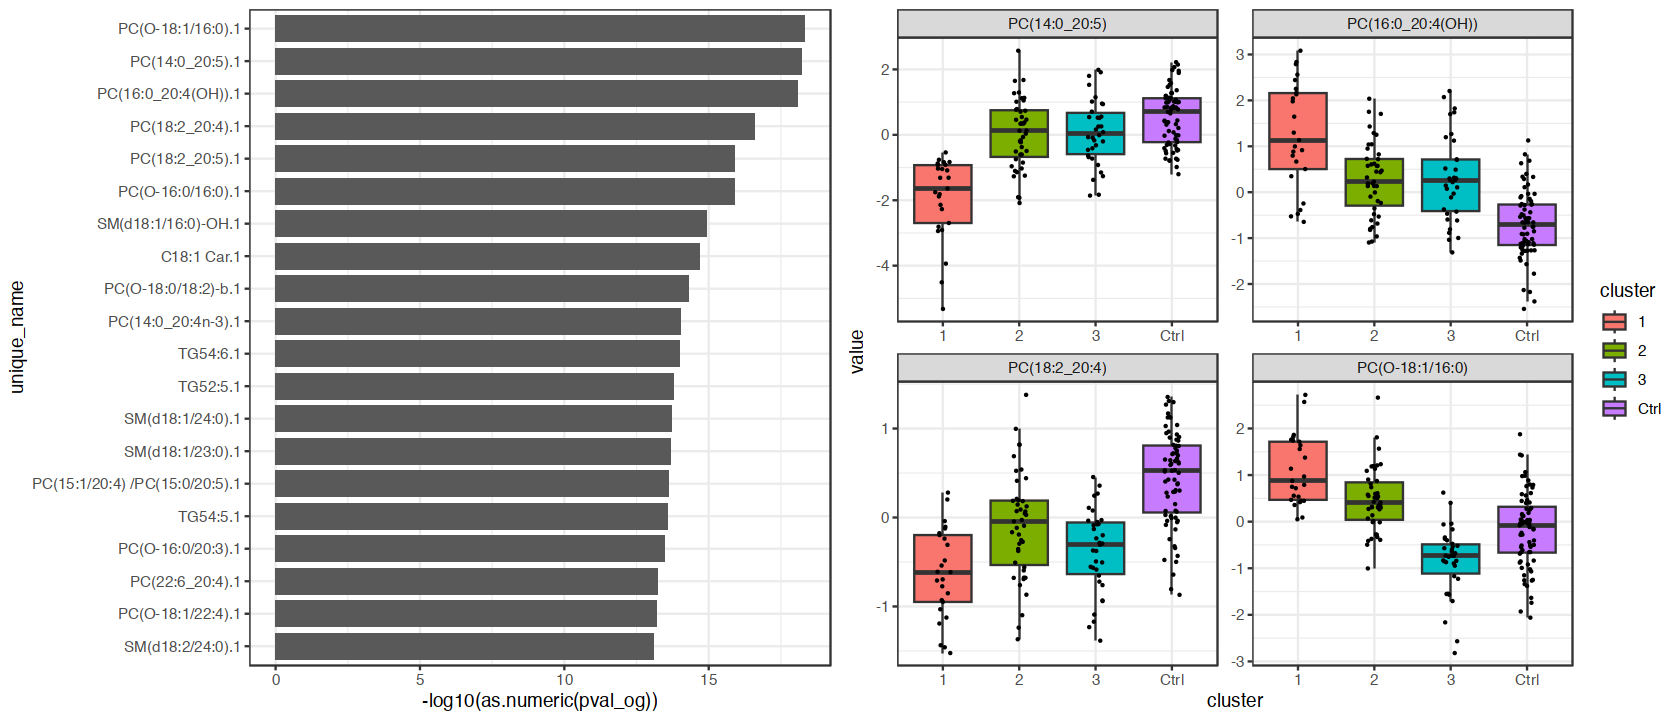

In [15]:
options(repr.plot.width = 14, repr.plot.height = 6)
cowplot::plot_grid(splot,bplot)

In [15]:
res$padj = p.adjust(res$pval_og, method = "BH")

[1] 161   6

In [19]:
df = data.frame(cbind(scaled_df[,paste0('X',rownames(subset(res,padj<0.000001)))],meta[rownames(scaled_df),'cluster']))
colnames(df)[ncol(df)]='cluster'
#df = df[grepl('^B',df$cluster),]
head(df)

,X51,X62,X38,X77,X78,X39,X110,X3,X49,X61,⋯,X84,X14,X5,X23,X86,X130,X87,X7,X27,cluster
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
X10299,-0.8962742,0.5245753,-0.4235839,0.2689971,-0.2362508,-0.3271079,-0.9352013,-1.1346356,-1.6482187,1.1147226,⋯,0.07651034,-1.24265366,-1.32083091,-0.8954101,-0.1635607,-0.4923745,-0.6933955,1.7193423,-0.7995986,B3
X10301,1.5660937,0.1245111,0.9490779,0.2096391,-0.5155569,1.7162072,0.5401833,0.9910490,1.0723793,0.4111046,⋯,0.76826780,-0.09761251,-1.12978061,0.2944526,1.4992116,-1.1464119,1.6372430,0.3388187,0.3123183,B2
X10302,0.3441947,1.0122242,-1.0963586,0.1843975,-1.0104882,0.1865964,-0.3984739,-0.1426653,0.3545399,2.0311372,⋯,1.17387720,-0.84749828,2.65792490,-1.7758412,0.8423726,-1.0365001,0.6405908,1.8133542,-0.6727850,B2
X10303,0.3178378,-0.1685108,0.8239293,-0.5950609,-0.8652420,0.7053985,1.0066932,1.6476913,0.4394994,-0.4080914,⋯,1.37938464,-0.45181875,0.54123967,-0.9237499,0.5561729,-0.1411722,0.4586153,0.1287547,-0.5623897,B2
X10304,0.7904085,-0.9263635,2.1331745,-1.4357671,-2.0994103,1.2263698,2.4666780,1.0550563,0.2077746,-0.5235422,⋯,-1.74609400,-0.54702362,0.57370132,-0.8165717,-1.8949527,-0.4836894,-2.1438720,-0.1194122,-0.9590665,B1
X10305,0.7476610,-3.9374224,0.3480225,-0.2375892,-2.3858413,1.7332140,0.3452155,0.2021826,-0.2571312,-2.1761035,⋯,-1.10780694,-1.01095271,0.07984628,-1.7667263,-0.2513519,0.9584755,-0.5835842,-0.8076673,-1.2598535,B1


In [20]:
ag = aggregate(df,by=list(df$cluster),mean)

Warning message in mean.default(X[[i]], ...):
“argument is not numeric or logical: returning NA”
Warning message in mean.default(X[[i]], ...):
“argument is not numeric or logical: returning NA”
Warning message in mean.default(X[[i]], ...):
“argument is not numeric or logical: returning NA”
Warning message in mean.default(X[[i]], ...):
“argument is not numeric or logical: returning NA”
Warning message in mean.default(X[[i]], ...):
“argument is not numeric or logical: returning NA”
Warning message in mean.default(X[[i]], ...):
“argument is not numeric or logical: returning NA”
Warning message in mean.default(X[[i]], ...):
“argument is not numeric or logical: returning NA”
Warning message in mean.default(X[[i]], ...):
“argument is not numeric or logical: returning NA”


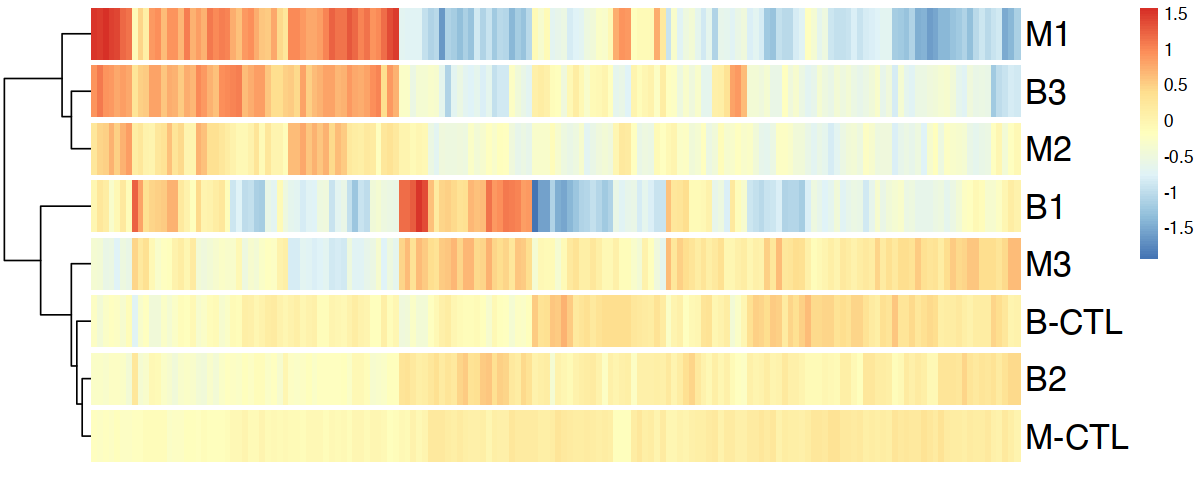

In [47]:
options(repr.plot.width = 10, repr.plot.height = 4)

rownames(ag) = ag[,1]
pheatmap::pheatmap(ag[,-c(1,ncol(ag))],
                   clustering_method='ward.D',
                   border_col='white',cutree_row=8,fontsize_col=1e-10,fontsize_row=20,treeheight_col=0)